# 01. TPE Disk Tracking — StarDist

**Pipeline step 1 of 3** — detects photoelastic disks in each frame and links them into trajectories, then computes continuous rotation angles from UV images.

## Inputs
- Green-channel fluorescence images (`Ic_*.png`) — for disk detection
- UV/blue-channel images (`Ic_*.png`, alternate index) — for orientation tracking
- PE images (`Ib_*.png`) — used for inspection only

## Outputs
- `<EXP_FOLDER>.pkl` — trajectory dataframe with columns:
  `frame, x, y, rpx, particle, boundary, angle`

## Workflow
1. Detect disks with StarDist2D → filter by area & eccentricity
2. Link detections into trajectories with Trackpy, interpolate gaps
3. Compute continuous rotation angles via PCA on UV images
4. Save trajectory to disk

### Imports

In [40]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import cv2
import os
import sys
from skimage import measure
from csbdeep.utils import normalize
from stardist.models import StarDist2D

### Utility functions

In [61]:
def max_num(img_dir, exp_folder):
    """Return the highest image index found in the experiment folder (Ic_*.png)."""
    files = os.listdir(os.path.join(img_dir, exp_folder))
    frame_numbers = [int(f.split('_')[1].split('.')[0]) for f in files
                     if f.startswith('Ic_') and f.endswith('.png')]
    return np.max(frame_numbers) if frame_numbers else 0


def camera_align(I):
    """Apply perspective correction (calibrated 20260304_2)."""
    H = np.array([[ 1.00654889e+00,  1.96540570e-02, -6.93742929e+00],
       [-1.82351292e-02,  1.01471559e+00, -2.83423136e+01],
       [-3.73774363e-06,  6.86833926e-07,  1.00000000e+00]])
    height, width = I.shape[:2]
    return cv2.warpPerspective(I, H, (width, height))


def PCA(I):
    """Return the principal direction vector and R² of a binary image."""
    y, x = np.nonzero(I)
    data = np.column_stack((x, y))
    centered = data - np.mean(data, axis=0)
    _, S, Vt = np.linalg.svd(centered)
    direction = Vt[0]
    R2 = S[0]**2 / (S[0]**2 + S[1]**2)
    return direction, R2


def interpolate_pos_angle(df):
    """Linearly interpolate x/y for frames where a particle was not detected."""
    new_rows = []
    total_missing = 0

    for pid, particle_data in df.groupby('particle'):
        particle_data = particle_data.set_index('frame').sort_index()
        frames = particle_data.index.to_numpy()
        if len(frames) == 0:
            continue

        missing = sorted(set(range(frames[0], frames[-1] + 1)) - set(frames))
        if not missing:
            continue

        total_missing += len(missing)
        placeholders = pd.DataFrame(index=missing, columns=particle_data.columns)
        placeholders['particle'] = pid
        placeholders.index.name = 'frame'

        combined = pd.concat([particle_data, placeholders]).sort_index()
        combined[['x', 'y']] = combined[['x', 'y']].interpolate(method='linear', limit_direction='both')
        for col in ['rpx']:
            combined[col] = combined[col].ffill().bfill()

        combined = combined.reset_index()
        new_rows.append(combined[combined['frame'].isin(missing)])

    if new_rows:
        df = pd.concat([df, *new_rows], ignore_index=True)

    df = df.sort_values(['particle', 'frame']).reset_index(drop=True)
    print(f'Interpolated {total_missing} missing positions.')
    return df


def crop_circle_with_mask_float(img):
    """Zero out pixels outside the inscribed circle of a square float image."""
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    radius = min(center[0], center[1])
    Y, X, C = np.ogrid[:h, :w, :3]
    mask = (X - center[0])**2 + (Y - center[1])**2 <= radius**2
    return img * mask


def generate_cropped_batch(f, img):
    """Crop, resize, and normalise one image patch per particle row in f."""
    batch = np.empty((len(f), 128, 128, 3), dtype=np.float32)
    h, w = img.shape[:2]
    for i in range(len(f)):
        row = f.iloc[i]
        x, y, r = int(np.around(row['x'])), int(np.around(row['y'])), int(row['rpx'])
        y1, y2 = max(0, y - r), min(h, y + r)
        x1, x2 = max(0, x - r), min(w, x + r)
        img_crop = img[y1:y2, x1:x2]
        img_crop = cv2.resize(img_crop, (128, 128), interpolation=cv2.INTER_AREA)
        img_crop = cv2.blur(img_crop, ksize=(3, 3)).astype(np.float32) / 255
        img_crop = crop_circle_with_mask_float(img_crop)
        batch[i] = img_crop
    return batch


def compute_continuous_angles(df):
    """Accumulate unwrapped rotation angles across frames for each particle.

    Handles the π-ambiguity of PCA orientation vectors: at each step the branch
    (raw_angle or raw_angle ± π) closest to the previous accumulated direction is
    chosen.  Operates on numpy arrays to avoid per-row pandas overhead.
    """
    df = df.sort_values(['particle', 'frame']).copy()
    df['angle'] = np.nan

    raw     = np.arctan2(df['dir_y'].to_numpy(dtype=float),
                         df['dir_x'].to_numpy(dtype=float))
    pids    = df['particle'].to_numpy()
    angle_out = np.full(len(df), np.nan)

    prev_raw: dict = {}
    prev_acc: dict = {}

    for k in range(len(df)):
        r = raw[k]
        if np.isnan(r):
            continue
        pid = pids[k]
        if pid not in prev_acc:
            prev_acc[pid] = r
            prev_raw[pid] = r
        else:
            pr   = prev_raw[pid]
            opt2 = r + np.pi if r < 0 else r - np.pi
            d1   = np.angle(np.exp(1j * (r    - pr)))
            d2   = np.angle(np.exp(1j * (opt2 - pr)))
            prev_acc[pid] += d1 if abs(d1) < abs(d2) else d2
            prev_raw[pid]  = r
        angle_out[k] = prev_acc[pid]

    df['angle'] = angle_out
    return df

def orientation_weighted_pca(img_gray):
    """
    Weighted PCA - uses intensity values as weights for sub-pixel precision.
    """
    from scipy.ndimage import gaussian_filter
    img = gaussian_filter(img_gray.astype(float), sigma=1.0)
    
    # Threshold to reduce background noise
    threshold = np.mean(img) + 0.5 * np.std(img)
    mask = img > threshold
    
    y, x = np.where(mask)
    weights = img[mask]
    
    if len(x) < 3:
        return np.array([1., 0.]), 0.0
    
    # Weighted centroid
    xc = np.average(x, weights=weights)
    yc = np.average(y, weights=weights)
    
    # Weighted covariance matrix
    x_centered = x - xc
    y_centered = y - yc
    
    cov_xx = np.average(x_centered * x_centered, weights=weights)
    cov_yy = np.average(y_centered * y_centered, weights=weights)
    cov_xy = np.average(x_centered * y_centered, weights=weights)
    
    cov_matrix = np.array([[cov_xx, cov_xy], [cov_xy, cov_yy]])
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    direction = eigenvectors[:, 1]
    R2 = eigenvalues[1]**2 / (eigenvalues[0]**2 + eigenvalues[1]**2) if eigenvalues.sum() > 0 else 0
    
    return direction, R2


def orientation_hybrid_correlation(img_gray, img_prev, angle_prev, n_samples=100, window_deg=5.0):
    """
    Hybrid method: temporal tracking via correlation with frame-to-frame accumulation.
    """
    # Ensure both images have the same shape
    if img_gray.shape != img_prev.shape:
        h = min(img_gray.shape[0], img_prev.shape[0])
        w = min(img_gray.shape[1], img_prev.shape[1])
        img_gray = cv2.resize(img_gray, (w, h), interpolation=cv2.INTER_LINEAR)
        img_prev = cv2.resize(img_prev, (w, h), interpolation=cv2.INTER_LINEAR)
    
    # Normalize both images for correlation
    img_gray_float = img_gray.astype(float)
    img_prev_float = img_prev.astype(float)
    img_gray_float = (img_gray_float - img_gray_float.mean()) / (img_gray_float.std() + 1e-8)
    img_prev_float = (img_prev_float - img_prev_float.mean()) / (img_prev_float.std() + 1e-8)
    
    # Generate RELATIVE rotation angles (centered at zero)
    window_rad = window_deg * np.pi / 180
    relative_angles = np.linspace(-window_rad, window_rad, n_samples)
    
    # Compute correlation for each rotation
    h, w = img_prev.shape
    center = (w / 2, h / 2)
    correlations = np.zeros(n_samples)
    for i, rel_angle in enumerate(relative_angles):
        M = cv2.getRotationMatrix2D(center, rel_angle * 180 / np.pi, 1.0)
        img_prev_rotated = cv2.warpAffine(img_prev_float, M, (w, h), flags=cv2.INTER_LINEAR)
        correlations[i] = np.sum(img_gray_float * img_prev_rotated)
    
    # Find peak correlation
    peak_idx = np.argmax(correlations)
    relative_angle_refined = relative_angles[peak_idx]
    
    # Accumulate: angle_current = angle_previous + relative_correction
    angle_refined = angle_prev + relative_angle_refined
    
    direction = np.array([np.cos(angle_refined), np.sin(angle_refined)])
    return direction

def draw_particle_orientation(
    img: np.ndarray,
    df: pd.DataFrame,
    x_col: str = 'x',
    y_col: str = 'y',
    angle_col: str = 'angle',
    linewidth: int = 1,
    linecolor: str = 'r',
    circle_color: str = 'r',
    show: bool = False
) -> np.ndarray:
    """Overlay orientation lines and circles on the image. Returns BGR array."""
    img_draw = img.copy()
    if img_draw.ndim == 2:
        img_draw = cv2.cvtColor(img_draw, cv2.COLOR_GRAY2BGR)

    # Keep only rows with a valid angle
    df_plot = df[df[angle_col].notnull()].copy()

    for idx, row in df_plot.iterrows():
        xc    = float(row[x_col])
        yc    = float(row[y_col])
        theta = float(row[angle_col])
        frame = int(row['frame']) if 'frame' in row else None
        half  = float(row['rpx'])

        dx = np.cos(theta) * half
        dy = np.sin(theta) * half

        # Draw symmetric orientation line
        pt1 = (int(round(xc - dx)), int(round(yc - dy)))
        pt2 = (int(round(xc + dx)), int(round(yc + dy)))
        color = np.array(mcolors.to_rgb(linecolor)) * 255
        cv2.line(img_draw, pt1, pt2, color, thickness=linewidth, lineType=cv2.LINE_AA)
        cv2.circle(img_draw, (int(round(xc)), int(round(yc))), int(row['rpx']),
                   np.array(mcolors.to_rgb(circle_color)) * 255,
                   thickness=linewidth, lineType=cv2.LINE_AA)

    if show:
        # Convert BGR to RGB for matplotlib display
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        title = 'Orientation overlay'
        if frame is not None:
            title += f' (frame {frame})'
        plt.title(title)
        plt.show()

    return img_draw


### Parameters — edit here before running

In [62]:
IMG_DIR    = r'N:\PROJ_TPE'
EXP_FOLDER = 'TPE_20260302A01_N=267x2_5e-4rps_5fps_steady_2000frames_denoise'
PKL_DIR    = r'M:\Archive\Proj_TPE\Disk_traj_files'

roi = (250, 1200, 0, 2000)  # (y_min, y_max, x_min, x_max)

# Derived values
max_index   = int(max_num(IMG_DIR, EXP_FOLDER))
max_frame   = max_index // 2
pickle_path = os.path.join(PKL_DIR, EXP_FOLDER)

print(f"Max image index: {max_index}")
print(f"Max frame:       {max_frame}")

Max image index: 4001
Max frame:       2000


### Load models

In [63]:
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_name = "stardist_09221229"
model = StarDist2D(None, name=model_name, basedir=MODEL_DIR)

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.724202, nms_thresh=0.3.


### Load images and predict

In [ ]:
axis_norm = (0,1)   # normalize channels independentl
import gc
import tensorflow as tf

records = [] #empty list to store results temporarily
k_list = np.zeros(max_frame+1, dtype=int)

for frame in range(1, max_frame + 1):
#for frame in range(1, 10):
    k = frame * 2 +1
    
    # Load both images
    path = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k:d}.png')
    I = camera_align(cv2.flip(cv2.imread(path), 1))
    
    sys.stdout.write(f"\rProcessing frame: {frame}, k = {k}")
    sys.stdout.flush()
    
    k_list[frame] = k # store k to note green index numbers for each frame

    Ig = I[roi[0]:roi[1], roi[2]:roi[3], 1] #GREEN CHANNEL 
    X = normalize(Ig,1,99.8,axis=axis_norm)
    #PREDICT 
    mask, detail = model.predict_instances(X, n_tiles=model._guess_n_tiles(X), show_tile_progress=False)

    # Compute properties
    props = measure.regionprops(mask)

    # Create a list of dicts
    for region in props:
        y, x = region.centroid  # note: (row, col) = (y, x)
        records.append({
            "frame": frame,
            "x": x,
            "y": y,
            "area": region.area,
            "ecc": region.eccentricity
        })

    # Delete large variables explicitly
    del I, Ig, X, mask, detail, props
    
    # Clear memory periodically
    if frame % 100 == 0:
        gc.collect()
        tf.keras.backend.clear_session()

df = pd.DataFrame.from_records(records)

Processing frame: 2000, k = 4001

### Filter Dataframe

In [65]:
df_filtered = df[(df["x"] < 1860)&(df["x"] > 100)&(df["y"] > 50)] #trim off boundary 
df_filtered = df_filtered[df_filtered["ecc"] < 0.6] #filter eccentricity #ecc filter changed to 0.6 20250923
df_filtered.loc[:,'rpx'] = 46 #add radius column
df_filtered.loc[df_filtered['area']<6000, 'rpx'] = 37


### Inspect detection in a random frame

Randomly selected frame: 630


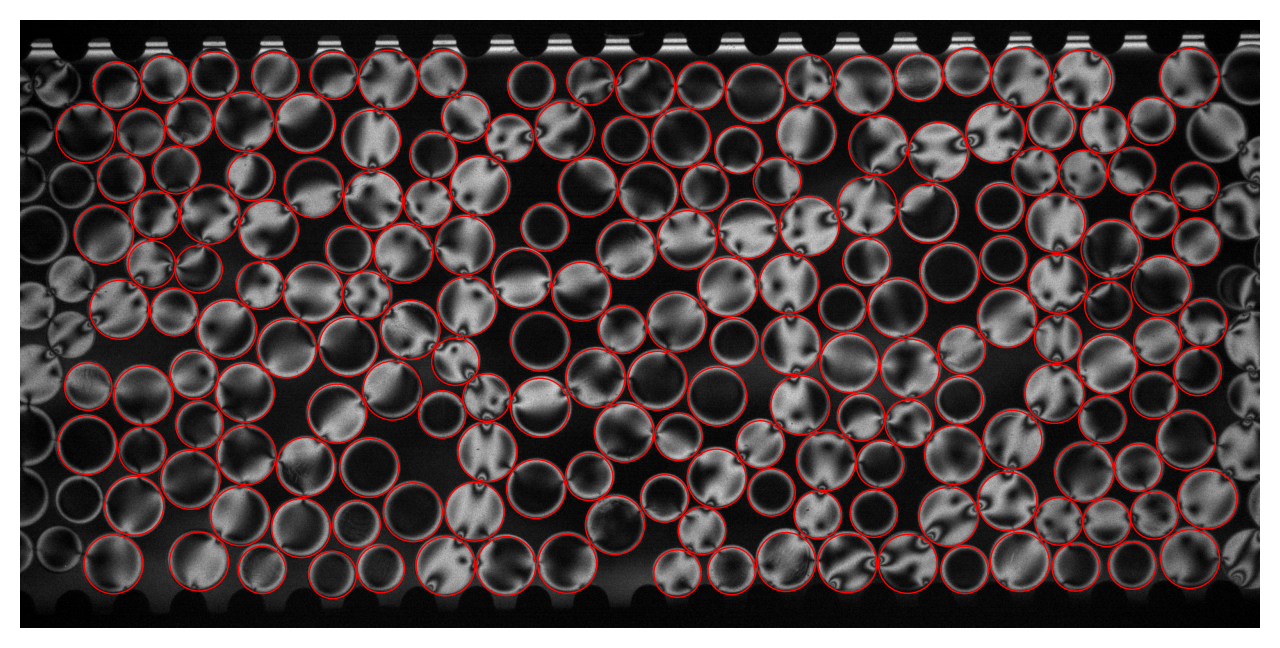

In [66]:
from matplotlib.patches import Circle

frame = np.random.choice(df_filtered['frame'].unique())
k = k_list[frame]
print(f"Randomly selected frame: {frame}")


path_bw = os.path.join(IMG_DIR, EXP_FOLDER, f'Ib_{frame+1}.png')
test_img = cv2.imread(path_bw)[roi[0]:roi[1], roi[2]:roi[3], 0]
#path_color = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k}.png')
#test_img = camera_align(cv2.flip(cv2.imread(path_color), 1))[roi[0]:roi[1], roi[2]:roi[3], 0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(test_img, cmap = 'gray')  # Your raw image

for _, row in df_filtered[(df_filtered.frame == frame)].iterrows():
    circ = Circle((row["x"], row["y"]), row["rpx"], edgecolor='red', facecolor='none', linewidth=0.5)
    ax.add_patch(circ)

plt.axis('off')
plt.show()


### Link coordinates into trajectory

In [67]:
import trackpy as tp

# link particles
F_linked = tp.link(df_filtered, search_range=30, memory=10)
F_linked = interpolate_pos_angle(F_linked)

# Mark boundary particles
F_linked['boundary'] = (F_linked.x < 200) | (F_linked.x > 1786) | (F_linked.y < 120) | (F_linked.y > 820)

# Change radius to mode value for each particle
F_linked['rpx'] = F_linked.groupby('particle')['rpx'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else x)


Frame 2000: 187 trajectories present.
Interpolated 28 missing positions.


### Find rotation angles

incorporated from TPE_rotation_angle_finder

In [68]:
records_rot = []  # collect (original_index, dir_x, dir_y, angle_R2) tuples
R2_list = []

# Initialize direction columns if they don't exist
if 'dir_x' not in F_linked.columns:
    F_linked['dir_x'] = np.nan
if 'dir_y' not in F_linked.columns:
    F_linked['dir_y'] = np.nan

# Pre-group 
grouped_linked = F_linked.groupby('frame')

#for frame in range(1, max_frame + 1):
for frame in range(1, max(F_linked['frame']) + 1):
    # Use the k value that was NOT chosen in the previous cell
    k1, k2 = frame * 2 + 1, frame * 2
    k = k2 if k_list[frame] == k1 else k1

    sys.stdout.write(f"\rProcessing frame: {frame}, k = {k}")
    sys.stdout.flush()

    path = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k:d}.png')
    I = camera_align(cv2.flip(cv2.imread(path), 1))
    I = I[roi[0]:roi[1], roi[2]:roi[3], 0]  # BLUE CHANNEL

    if frame not in grouped_linked.groups:
        continue
    f = grouped_linked.get_group(frame)

    for id, row in f.iterrows():
        yc, xc = row['y'], row['x']
        roi_half_length = row['rpx'] * 0.6  # length of the bar
        y1, y2 = int(yc - roi_half_length), int(yc + roi_half_length)
        x1, x2 = int(xc - roi_half_length), int(xc + roi_half_length)
        uv_roi = I[y1:y2, x1:x2]
        if uv_roi.size > 0 and uv_roi.shape[0] > 0 and uv_roi.shape[1] > 0:
            uv_roi = cv2.GaussianBlur(uv_roi, (5, 5), 1)
            direction, R2 = orientation_weighted_pca(uv_roi)  # weighted PCA on grayscale
            records_rot.append((id, direction[0], direction[1], R2))
            R2_list.append(R2)

# Bulk-assign all rotation results in one shot (avoids repeated F_linked.loc[] writes)
if records_rot:
    rot_df = pd.DataFrame(records_rot,
                          columns=['_idx', 'dir_x', 'dir_y', 'angle_R2']
                          ).set_index('_idx')
    F_linked.update(rot_df)

F_linked = compute_continuous_angles(F_linked)
F_linked.drop(['dir_x', 'dir_y'], axis=1, inplace=True)

Processing frame: 2000, k = 4000

112 56


(-0.5, 1935.5, 949.5, -0.5)

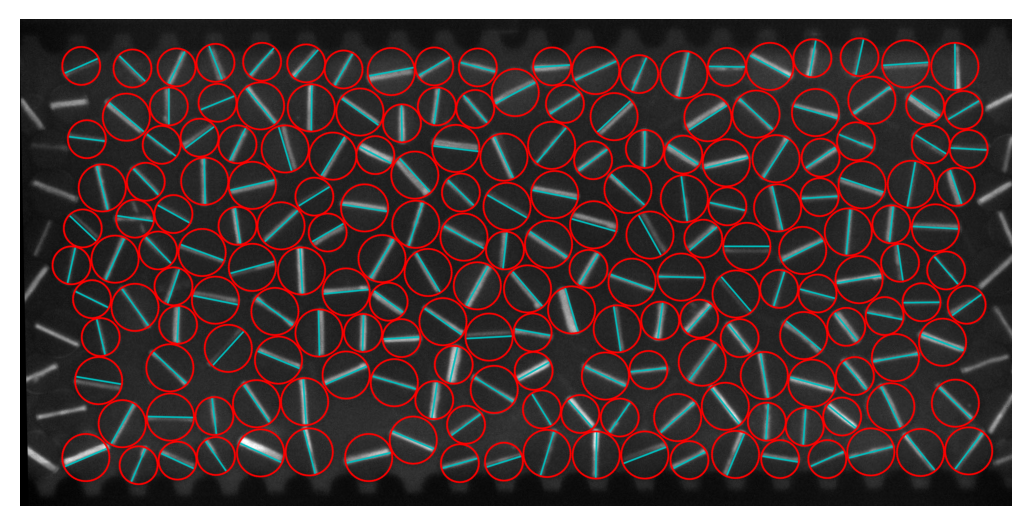

In [69]:
plt.rcParams['figure.dpi'] = 200

frame = np.random.choice(F_linked['frame'].unique())
k1 = frame * 2 + 1
k2 = frame * 2
k_chosen = k_list[frame]

if k_chosen == k1:
    k = k2
else:
    k = k1

print(k, frame)
path = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k:d}.png')
I = camera_align(cv2.flip(cv2.imread(path), 1))
I = I[roi[0]:roi[1], roi[2]:roi[3], 0] #BLUE CHANNEL 
if I.ndim == 2:  
    I = cv2.cvtColor(I, cv2.COLOR_GRAY2BGR)

    
res = draw_particle_orientation(I.copy(),F_linked[(F_linked.frame==frame)], show = False, linecolor='c', linewidth=2)
plt.imshow(res)
plt.axis('off')

### DoG Refinement of disk centers for improved tracking accuracy


In [70]:

def dog_kernel(r_center, delta, sigma):
    """Create a radial Difference of Gaussians kernel for edge detection."""
    kernel_size = 2 * r_center + 2 * sigma
    yy_k, xx_k = np.ogrid[-r_center-2*sigma:r_center+2*sigma+1, -r_center-2*sigma:r_center+2*sigma+1]
    rr_k = np.sqrt(xx_k**2 + yy_k**2)
    
    # Negative peak at r - delta (inner Gaussian)
    inner_gaussian = -np.exp(-((rr_k - (r_center - delta))**2) / (2 * sigma**2))
    # Positive peak at r + delta (outer Gaussian)
    outer_gaussian = np.exp(-((rr_k - (r_center + delta))**2) / (2 * sigma**2))
    
    kernel = inner_gaussian + outer_gaussian
    kernel /= np.max(np.abs(kernel))  # Normalize
    return kernel.astype(np.float32)


def fit_refined_centroid(patch):
    """Compute intensity-weighted centroid of a patch for sub-pixel refinement."""
    h, w = patch.shape
    p_min = patch.min()
    safe_patch = patch - p_min
    weights = safe_patch ** 2  # Square for sharpening
    
    sum_w = np.sum(weights)
    if sum_w == 0:
        return w/2, h/2, 0
    
    yy, xx = np.mgrid[0:h, 0:w]
    cx = np.sum(xx * weights) / sum_w
    cy = np.sum(yy * weights) / sum_w
    rss = np.var(weights)
    
    return cx, cy, rss


# Apply DoG refinement to all detections before saving
print("Applying DoG refinement to disk centers...")

# Create kernels for two disk sizes
big_kernel = dog_kernel(49, delta=3, sigma=2)    # for rpx=46 disks
small_kernel = dog_kernel(40, delta=3, sigma=2)  # for rpx=37 disks

# Store refined positions
refined_data = []
max_frame_refine = int(F_linked['frame'].max())

for frame in range(1, max_frame_refine + 1):
    frame_data = F_linked[F_linked['frame'] == frame]
    
    k = k_list[frame]
    path = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k:d}.png')
    I_frame = camera_align(cv2.flip(cv2.imread(path), 1))
    Ig_frame = I_frame[roi[0]:roi[1], roi[2]:roi[3], 0].astype(np.float32)
    
    # Normalize for convolution
    Ig_norm = (Ig_frame - Ig_frame.min()) / (Ig_frame.max() - Ig_frame.min() + 1e-6)
    
    # Apply both DoG kernels
    dog_response_big = cv2.filter2D(Ig_norm, -1, big_kernel)
    dog_response_big = dog_response_big - 100
    dog_response_big[dog_response_big < 0] = 0
    
    dog_response_small = cv2.filter2D(Ig_norm, -1, small_kernel)
    dog_response_small = dog_response_small - 100
    dog_response_small[dog_response_small < 0] = 0
    
    for idx, row in frame_data.iterrows():
        x_c, y_c = float(row['x']), float(row['y'])
        r = float(row['rpx'])
        
        # Select appropriate kernel and response
        if r == 46:
            dog_response = dog_response_big
        else:  # r == 37
            dog_response = dog_response_small
        
        # Extract patch from DoG response
        roi_half = int(max(1, round(0.25 * r)))
        x0 = int(max(0, round(x_c - roi_half)))
        y0 = int(max(0, round(y_c - roi_half)))
        x1 = int(min(dog_response.shape[1], round(x_c + roi_half)))
        y1 = int(min(dog_response.shape[0], round(y_c + roi_half)))
        
        patch_dog = dog_response[y0:y1, x0:x1].copy()
        
        # Fit centroid on DoG response
        cx_patch, cy_patch, rss = fit_refined_centroid(patch_dog)
        
        # Convert back to global coordinates
        x_refined = cx_patch + x0
        y_refined = cy_patch + y0
        
        # Validate shift and apply refinement
        max_shift = 10
        shift_dist = np.hypot(x_refined - x_c, y_refined - y_c)
        
        if shift_dist > max_shift or not np.isfinite(x_refined) or not np.isfinite(y_refined):
            x_refined, y_refined = x_c, y_c
            shift_dist = 0.0
        
        # Copy row and update coordinates
        row_refined = row.copy()
        row_refined['x'] = float(x_refined)
        row_refined['y'] = float(y_refined)
        row_refined['refine_shift'] = float(shift_dist)
        refined_data.append(row_refined)
    
    if frame % max(1, max_frame_refine // 10) == 0:
        print(f"  Refined frame {frame}/{max_frame_refine}")

# Replace F_linked with refined version
F_linked = pd.DataFrame(refined_data).reset_index(drop=True)
print(f"DoG refinement complete. Refined {len(F_linked)} detections.")


Applying DoG refinement to disk centers...
  Refined frame 200/2000
  Refined frame 400/2000
  Refined frame 600/2000
  Refined frame 800/2000
  Refined frame 1000/2000
  Refined frame 1200/2000
  Refined frame 1400/2000
  Refined frame 1600/2000
  Refined frame 1800/2000
  Refined frame 2000/2000
DoG refinement complete. Refined 372889 detections.


Randomly selected frame: 65


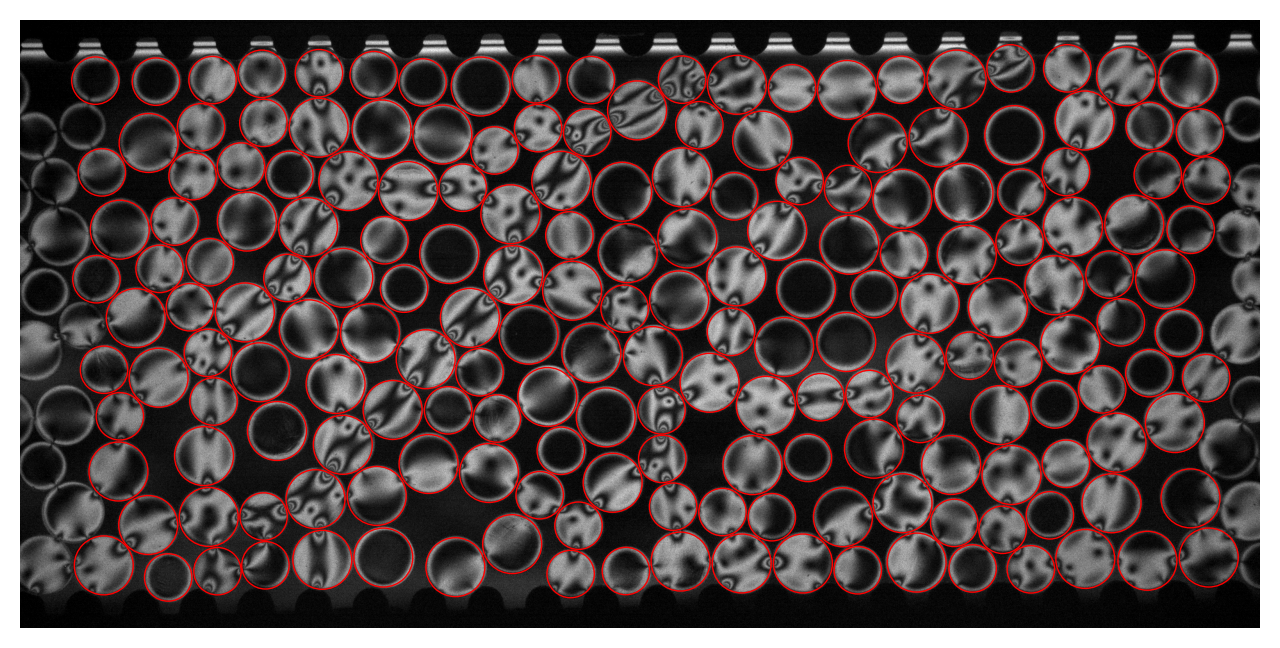

In [73]:
from matplotlib.patches import Circle

frame = np.random.choice(F_linked['frame'].unique())
k = k_list[frame]
print(f"Randomly selected frame: {frame}")

path_bw = os.path.join(IMG_DIR, EXP_FOLDER, f'Ib_{frame}.png')
test_img = cv2.imread(path_bw)[roi[0]:roi[1], roi[2]:roi[3], 0]
#path_color = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k}.png')
#test_img = camera_align(cv2.flip(cv2.imread(path_color), 1))[roi[0]:roi[1], roi[2]:roi[3], 0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(test_img, cmap = 'gray')  # Your raw image

for _, row in F_linked[(F_linked.frame == frame)].iterrows():
    circ = Circle((row["x"], row["y"]), row["rpx"], edgecolor='red', facecolor='none', linewidth=0.5)
    ax.add_patch(circ)

#for _, row in df_filtered[(df_filtered.frame == frame)].iterrows():
#    circ = Circle((row["x"], row["y"]), row["rpx"], edgecolor='blue', facecolor='none', linewidth=0.5)
#    ax.add_patch(circ)

plt.axis('off')
plt.show()

### save to disk

In [74]:
F_linked.to_pickle(str(pickle_path+'.pkl'))